In [4]:
import sys

import hyperspy.api as hs
import matplotlib.pyplot as plt
import numpy as np

sys.path.append('..')
import roi_tools


In [5]:
s_original = hs.load('../data/images/Jaume LFO/HAADF_Buena.dm3')

left_bound = 20
right_bound = 2048 - 20
start_pixel = 200
end_pixel = 2048 - 100

s = s_original.isig[left_bound:right_bound, start_pixel:end_pixel]


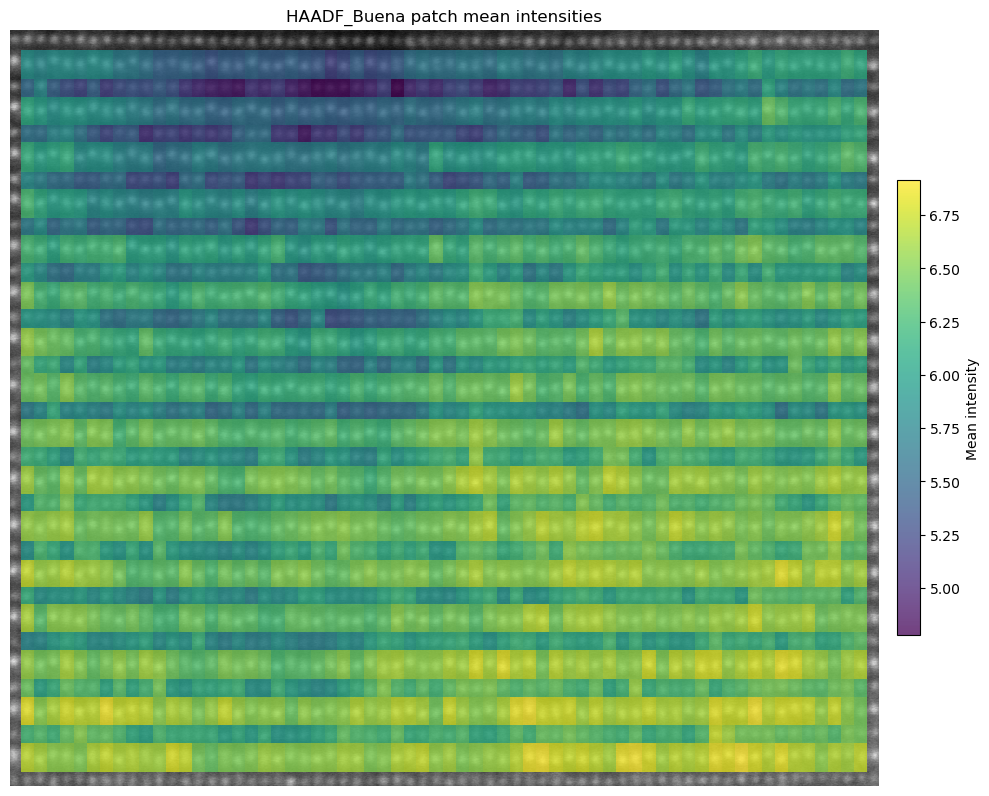

In [6]:
grid_creator = roi_tools.GridCreator()
layout = grid_creator.detect_layout(s)
grid = grid_creator.process(s, layout=layout)
mean_intensities = grid.values(metric='mean_intensity')

fig, ax = plt.subplots(figsize=(10, 10))
plotter = roi_tools.PatchGridPlotter(s, grid, ax=ax)

artist = plotter.add_patch_faces(
    values=mean_intensities,
    cmap='viridis',
    alpha=0.75,
)

fig.colorbar(artist, ax=ax, fraction=0.025, pad=0.02, label='Mean intensity')
ax.set_title('HAADF_Buena patch mean intensities')
ax.axis('off')
fig.tight_layout()
plt.show()
